# AAV5 -- Sorting the dataset to remove blatant apparition of contamination

See below, the dataset is strongly contaminated by the 7m8 variant. Mutations of the 7m8 are also among the most populated variants. 
These mutations are an issue as their appear in the count for plasmid bu as they are only mutations, they disappear for the post viability 
results. Therefore their log enrichment is terrible while not being bad variants.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- locate the confidential AAV5 organoid CSV (never commit / push / upload) ---
CSV_PATH = Path("AAV5_organoides.csv")
if not CSV_PATH.exists():
    here = Path.cwd()
    root = next(p for p in [here, *here.parents] if p.name == "Modelization_V2")
    CSV_PATH = root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides.csv"
assert CSV_PATH.exists(), CSV_PATH

count_cols = [
    "compte_plasmide", "compte_virus",
    "compte_organoide_1_adn", "compte_organoide_1_arn",
    "compte_organoide_2_adn", "compte_organoide_2_arn",
    "compte_organoide_3_adn", "compte_organoide_3_arn",
    "compte_noyaux_1_adn", "compte_noyaux_1_arn",
    "compte_noyaux_2_adn", "compte_noyaux_2_arn",
    "compte_noyaux_moyenne_adn", "compte_noyaux_moyenne_arn",
    "compte_controle_negatif",
]
log2_cols = [c for c in pd.read_csv(CSV_PATH, nrows=0).columns if c.startswith("log2_")]
dtypes = {"sequence": "string",
          **{c: "float32" for c in count_cols},
          **{c: "float32" for c in log2_cols}}

df = pd.read_csv(CSV_PATH, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)

# viability = log2(virus / plasmide) ; selectivity = log2(ADN organoide / virus), 3 replicates
viab_col  = "log2_enrichissement_virus_sur_plasmide"
sel_cols  = [f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)]
viab_cnt  = ["compte_plasmide", "compte_virus"]
sel_cnt   = [f"compte_organoide_{i}_adn" for i in (1, 2, 3)]
df.head()

(5595543, 35)


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide,compte_organoide_1_adn,compte_organoide_1_arn,log2_enrichissement_organoide_1_adn_sur_virus,log2_enrichissement_organoide_1_arn_sur_virus,log2_enrichissement_organoide_1_arn_sur_adn,compte_organoide_2_adn,...,compte_noyaux_2_arn,log2_enrichissement_noyaux_2_adn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_adn,compte_noyaux_moyenne_adn,compte_noyaux_moyenne_arn,log2_enrichissement_noyaux_moyenne_adn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_adn,compte_controle_negatif
0,TEVDRMT,36.5,0.5,-4.928953,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
1,VPQEVVR,8.5,50.5,3.831620,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
2,TGRSDAQ,10.0,8.5,1.026406,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
3,PIRINSN,14.5,1.0,-2.597110,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
4,GDTIAMV,8.5,6.0,0.758371,0.0,0.0,NaN,NaN,NaN,6.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0


In [2]:
# Hamming distance of every variant to the 7m8 spike-in (LGETTRP), computed once.
WT = "LGETTRP"
char = np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8).reshape(len(df), 7)
ham  = (char != np.frombuffer(WT.encode(), np.uint8)).sum(axis=1).astype(np.int16)
df["hamming_to_7m8"] = ham
wt_row = int(np.flatnonzero(ham == 0)[0])
print(f"7m8 (LGETTRP) at row {wt_row}")
print(df["hamming_to_7m8"].value_counts().sort_index())

7m8 (LGETTRP) at row 1650217
hamming_to_7m8
0          1
1         66
2        207
3       2877
4      43273
5     369171
6    1715820
7    3464128
Name: count, dtype: int64


## 1. Classements par colonne de comptage

Variants tries par comptage decroissant, `comptage vs rang` en log-log. Le rang du 7m8 (`LGETTRP`)
et de ses mutants a 1 substitution est marque : sur le plasmide ils sont tout en haut du classement,
apres la selection de viabilite (virus) et dans les organoides ils s'effondrent.

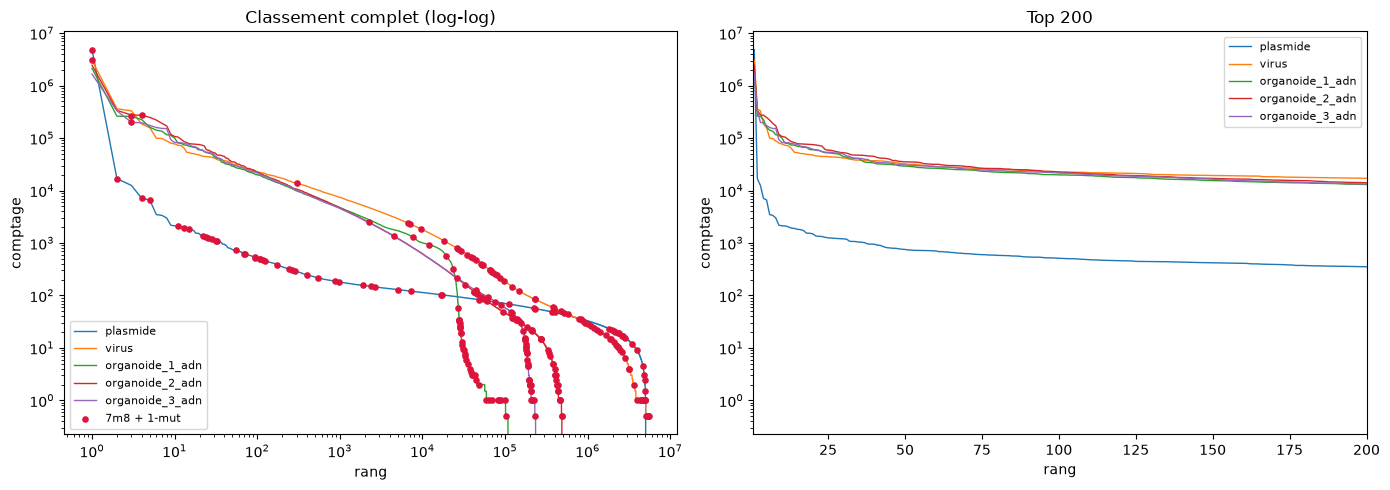

In [3]:
focus = ["compte_plasmide", "compte_virus",
         "compte_organoide_1_adn", "compte_organoide_2_adn", "compte_organoide_3_adn"]

near1 = np.flatnonzero(ham <= 1)          # 7m8 + its single mutants
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col in focus:
    v = df[col].to_numpy(np.float64)
    order = np.argsort(v)[::-1]
    rank_of = np.empty(len(v), np.int64); rank_of[order] = np.arange(len(v))
    vs = v[order]
    x = np.arange(1, len(vs) + 1)
    axes[0].plot(x, vs, lw=1, label=col.replace("compte_", ""))
    axes[1].plot(x, vs, lw=1, label=col.replace("compte_", ""))
    r7 = rank_of[near1] + 1
    axes[0].scatter(r7, v[near1], s=14, color="crimson", zorder=5)
axes[0].scatter([], [], s=14, color="crimson", label="7m8 + 1-mut")
axes[0].set(xscale="log", yscale="log", xlabel="rang", ylabel="comptage",
            title="Classement complet (log-log)")
axes[1].set(xlim=(0.7, 200), yscale="log", xlabel="rang", ylabel="comptage",
            title="Top 200")
axes[0].legend(fontsize=8, loc="lower left"); axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()


In [4]:
# fichier des classements : une ligne par variant, rang (1 = plus abondant, ex-aequo -> même rang)
# dans chaque colonne de comptage, trié par rang plasmide. Gitignoré (**/*organoides*.csv).
rank_cols = ["compte_plasmide", "compte_virus",
             "compte_organoide_1_adn", "compte_organoide_2_adn", "compte_organoide_3_adn"]
classements = df[["sequence", "hamming_to_7m8", *rank_cols]].copy()
for c in rank_cols:
    classements[f"rang_{c.replace('compte_', '')}"] = (
        df[c].rank(ascending=False, method="min").astype("int64"))
classements = classements.sort_values("rang_plasmide").reset_index(drop=True)

OUT_RANK = CSV_PATH.with_name("AAV5_organoides_classements.csv")
classements.to_csv(OUT_RANK, index=False)
print(f"écrit {OUT_RANK.name}  ({classements.shape[0]:,} lignes x {classements.shape[1]} colonnes)")
classements.head(20)


écrit AAV5_organoides_classements.csv  (5,595,543 lignes x 12 colonnes)


,sequence,hamming_to_7m8,compte_plasmide,compte_virus,compte_organoide_1_adn,compte_organoide_2_adn,compte_organoide_3_adn,rang_plasmide,rang_virus,rang_organoide_1_adn,rang_organoide_2_adn,rang_organoide_3_adn
0,LGETTRP,0,4845391.5,3043832.5,258603.0,273123.0,199407.5,1,1,3,4,3
1,LGETTRH,1,16921.5,13860.0,325.0,2506.5,1356.5,2,302,23568,2249,4487
2,TPANSTK,7,12492.5,5413.5,38.5,26.0,0.0,3,1777,27721,175908,233975
3,LCETTRP,1,7071.0,2380.5,6.0,86.0,4.5,4,6743,33180,55373,189303
4,LGETTIP,1,6615.5,2295.5,7.0,48.5,47.0,5,7110,32324,94990,119983
5,IADNRVS,7,3480.0,361759.5,60589.0,47510.5,57921.5,6,2,19,33,22
6,NHPNSID,7,3364.0,329851.0,17048.5,12495.5,16785.0,7,3,131,236,147
7,LPENSID,5,3001.5,1313.0,1974.5,4.0,3.0,8,14822,3625,386347,192546
8,TTKKNSE,7,2177.5,975.5,0.0,0.0,0.0,9,20879,108371,486845,233975
9,HLSNSID,7,2124.5,918.5,47.0,62.0,0.0,10,22335,27486,74380,233975


## 2. Distribution des log enrichments (dataset brut)

Colonnes `log2_enrichissement_*` telles quelles (avant tout tri). Beaucoup de valeurs sont NaN
(0 comptage organoide -> log indefini) : la fraction finie est indiquee par panneau. Trait noir = 0,
trait rouge pointille = valeur du 7m8.

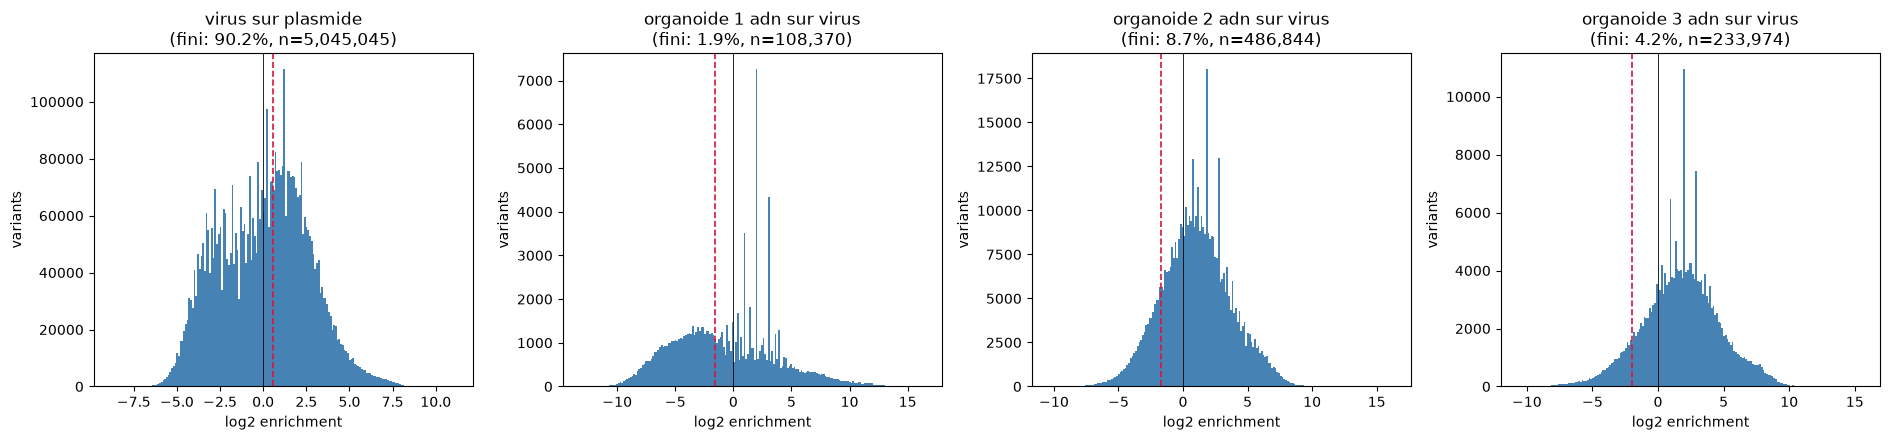

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, col in zip(axes, [viab_col, *sel_cols]):
    x = df[col].to_numpy(np.float64)
    finite = np.isfinite(x)
    ax.hist(x[finite], bins=200, color="steelblue")
    ax.axvline(0, color="k", lw=0.6)
    if finite[wt_row]:
        ax.axvline(x[wt_row], color="crimson", ls="--", lw=1.2)
    short = col.replace("log2_enrichissement_", "").replace("_", " ")
    ax.set(title=f"{short}\n(fini: {finite.mean():.1%}, n={int(finite.sum()):,})",
           xlabel="log2 enrichment", ylabel="variants")
plt.tight_layout(); plt.show()

## 3. Contamination 7m8 et ses mutations

`LGETTRP` (7m8) domine le plasmide **et** le virus (spike-in / contamination reelle). Ses mutations
a 1-2 substitutions apparaissent en masse sur le plasmide mais s'effondrent apres la viabilite :
leur log enrichment de viabilite est tres negatif alors que ce ne sont pas de mauvais variants --
juste des lectures erronees du 7m8. Le tableau liste les variants a `hamming <= 2` tries par comptage
plasmide.

In [6]:
near2 = np.flatnonzero(ham <= 2)
cols_show = ["sequence", "hamming_to_7m8", "compte_plasmide", "compte_virus",
            *sel_cnt, viab_col]
t = df.iloc[near2][cols_show].sort_values("compte_plasmide", ascending=False).reset_index(drop=True)
print(f"{len(near2)} variants a hamming <= 2 du 7m8 "
      f"({int((ham == 1).sum())} a 1 mut, {int((ham == 2).sum())} a 2 mut)")
with pd.option_context("display.max_rows", 60, "display.width", 200):
    display(t.head(60))

274 variants a hamming <= 2 du 7m8 (66 a 1 mut, 207 a 2 mut)


,sequence,hamming_to_7m8,compte_plasmide,compte_virus,compte_organoide_1_adn,compte_organoide_2_adn,compte_organoide_3_adn,log2_enrichissement_virus_sur_plasmide
0,LGETTRP,0,4845391.5,3043832.5,258603.0,273123.0,199407.5,0.590147
1,LGETTRH,1,16921.5,13860.0,325.0,2506.5,1356.5,0.972941
2,LCETTRP,1,7071.0,2380.5,6.0,86.0,4.5,-0.309778
3,LGETTIP,1,6615.5,2295.5,7.0,48.5,47.0,-0.266170
4,VGETTRP,1,2115.5,189.0,7.5,22.0,8.0,-2.223669
5,LGETTRT,1,1924.0,1098.0,936.0,5.0,4.5,0.451641
6,IGETTRP,1,1826.0,718.5,3.0,38.0,2.0,-0.084755
7,LGKTTRP,1,1340.0,517.0,1289.0,118.5,217.5,-0.113126
8,HGETTRP,1,1285.5,148.0,5.0,5.0,9.0,-1.857789
9,LSETTRP,1,1254.0,807.5,58.0,81.5,94.0,0.625868


In [7]:
# Top 30 variants du plasmide : lesquels sont lies au 7m8, lesquels sont une autre contamination ?
top = df.nlargest(30, "compte_plasmide")[
    ["sequence", "hamming_to_7m8", "compte_plasmide", "compte_virus", viab_col]
].reset_index(drop=True)
top["lie_7m8"] = top["hamming_to_7m8"] <= 2
display(top)

# masque de contamination propose (NON sauvegarde) : 7m8 + mutations proches tres abondantes
# sur le plasmide. Seuil choisi dans le "trou" du classement plasmide (cf. section 1).
CONTAM_PLASMID_MIN = 5e3
contam_mask = (ham <= 2) & (df["compte_plasmide"].to_numpy() >= CONTAM_PLASMID_MIN)
contam_mask |= (ham == 0)
print(f"\nmasque contamination : {int(contam_mask.sum())} variants")
print(df["sequence"][contam_mask].tolist())

,sequence,hamming_to_7m8,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide,lie_7m8
0,LGETTRP,0,4845391.5,3043832.5,0.590147,True
1,LGETTRH,1,16921.5,13860.0,0.972941,True
2,TPANSTK,7,12492.5,5413.5,0.054443,False
3,LCETTRP,1,7071.0,2380.5,-0.309778,True
4,LGETTIP,1,6615.5,2295.5,-0.266170,True
5,IADNRVS,7,3480.0,361759.5,7.960671,False
6,NHPNSID,7,3364.0,329851.0,7.876364,False
7,LPENSID,5,3001.5,1313.0,0.068055,False
8,TTKKNSE,7,2177.5,975.5,0.102412,False
9,HLSNSID,7,2124.5,918.5,0.051100,False



masque contamination : 4 variants
['LCETTRP', 'LGETTIP', 'LGETTRH', 'LGETTRP']


## 4. Variants a faible comptage (viab & sel < 5)

`viab` = comptages `compte_plasmide` / `compte_virus` ; `sel` = comptages `compte_organoide_{1,2,3}_adn`.
Un variant sous ~5 lectures des deux cotes ne porte quasiment pas d'information exploitable.

In [8]:
THR = 5
N = len(df)
viab_arr = df[viab_cnt].to_numpy(np.float64)          # (N, 2)
sel_arr  = df[sel_cnt].to_numpy(np.float64)           # (N, 3)

# par colonne
per_col = pd.DataFrame({
    "n_count<5":  [int((df[c].to_numpy() < THR).sum()) for c in viab_cnt + sel_cnt],
    "frac":       [float((df[c].to_numpy() < THR).mean()) for c in viab_cnt + sel_cnt],
}, index=viab_cnt + sel_cnt)
display(per_col.round(4))

viab_low_all = (viab_arr < THR).all(axis=1)           # plasmide ET virus < 5
viab_low_any = (viab_arr < THR).any(axis=1)
sel_low_all  = (sel_arr  < THR).all(axis=1)           # les 3 replicats organoide < 5
sel_low_any  = (sel_arr  < THR).any(axis=1)

summary = pd.DataFrame({
    "n_variants": [
        int(viab_low_all.sum()),
        int(sel_low_all.sum()),
        int((viab_low_all & sel_low_all).sum()),
        int((viab_low_any & sel_low_any).sum()),
    ],
}, index=[
    "viab < 5  (plasmide ET virus)",
    "sel < 5   (organoide 1 ET 2 ET 3)",
    "viab < 5  ET  sel < 5   (les deux, strict)",
    "viab < 5  ET  sel < 5   (au moins une colonne de chaque)",
])
summary["frac"] = (summary["n_variants"] / N).round(4)
display(summary)
print(f"total variants : {N:,}")

,n_count<5,frac
compte_plasmide,968870,0.1732
compte_virus,2501053,0.4470
compte_organoide_1_adn,5559814,0.9936
compte_organoide_2_adn,5211548,0.9314
compte_organoide_3_adn,5406241,0.9662


,n_variants,frac
viab < 5 (plasmide ET virus),710613,0.1270
sel < 5 (organoide 1 ET 2 ET 3),5132059,0.9172
"viab < 5 ET sel < 5 (les deux, strict)",703743,0.1258
viab < 5 ET sel < 5 (au moins une colonne de chaque),2757696,0.4928


total variants : 5,595,543


## 5. CSV de travail

Filtre retenu (bornes fixées après les explorations §6 / §7) :

- **hamming ≤ 2 du 7m8** (`LGETTRP`) retiré : le 7m8 et ses (mis)lectures proches polluent le
  plasmide et faussent le log enrichment de viabilité.
- **10 ≤ compte_plasmide ≤ 500** : sous 10 lectures en entrée le signal est trop bruité ;
  au-dessus de 500 on retire les quelques variants sur-représentés (spike-ins / contaminations).

Sortie : `AAV5_organoides_sorted.csv` — **le CSV de travail** du projet AAV5 sélectivité
(gitignoré, `**/*organoides*.csv`).


In [9]:
HAM_MAX      = 2      # drop variants within this Hamming distance of 7m8 (LGETTRP)
PLASMID_MIN  = 10     # drop variants with fewer than this many plasmid reads
PLASMID_MAX  = 500    # drop variants with more than this many plasmid reads

pl           = df["compte_plasmide"].to_numpy()
drop_ham     = df["hamming_to_7m8"].to_numpy() <= HAM_MAX
drop_plasmid = (pl < PLASMID_MIN) | (pl > PLASMID_MAX)
keep         = ~(drop_ham | drop_plasmid)

N = len(df)
n_drop_plasmid = int(drop_plasmid.sum())
print(f"variants initiaux                    : {N:,}")
print(f"  retires hamming <= {HAM_MAX}               : {int(drop_ham.sum()):,}")
print(f"  retires plasmide hors [{PLASMID_MIN}, {PLASMID_MAX}]  : {n_drop_plasmid:,}")
print(f"  retires (union)                     : {int((~keep).sum()):,}")
print(f"variants conserves (CSV de travail)  : {int(keep.sum()):,}  ({keep.mean():.1%})")

df_sorted = df.loc[keep].drop(columns=["hamming_to_7m8"]).reset_index(drop=True)
df_sorted.head()


variants initiaux                    : 5,595,543
  retires hamming <= 2               : 274
  retires plasmide hors [10, 500]  : 1,773,022
  retires (union)                     : 1,773,143
variants conserves (CSV de travail)  : 3,822,400  (68.3%)


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide,compte_organoide_1_adn,compte_organoide_1_arn,log2_enrichissement_organoide_1_adn_sur_virus,log2_enrichissement_organoide_1_arn_sur_virus,log2_enrichissement_organoide_1_arn_sur_adn,compte_organoide_2_adn,...,compte_noyaux_2_arn,log2_enrichissement_noyaux_2_adn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_adn,compte_noyaux_moyenne_adn,compte_noyaux_moyenne_arn,log2_enrichissement_noyaux_moyenne_adn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_adn,compte_controle_negatif
0,TEVDRMT,36.5,0.5,-4.928953,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
1,TGRSDAQ,10.0,8.5,1.026406,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
2,PIRINSN,14.5,1.0,-2.597110,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
3,GNLRVIL,35.5,10.0,-0.566948,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
4,MNTEPRM,42.0,9.0,-0.961521,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0


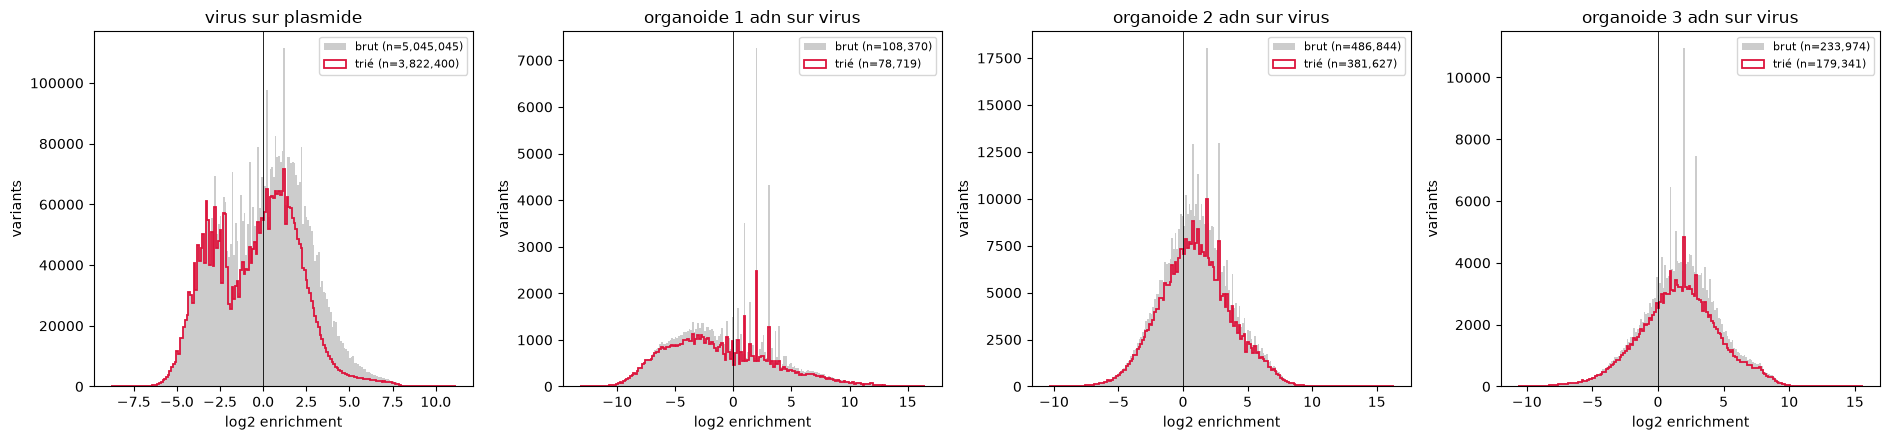

écrit AAV5_organoides_sorted.csv  (3,822,400 lignes x 35 colonnes)


In [10]:
# effet du tri sur les distributions de log enrichment (avant / après)
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, col in zip(axes, [viab_col, *sel_cols]):
    a = df[col].to_numpy(np.float64);        a = a[np.isfinite(a)]
    b = df_sorted[col].to_numpy(np.float64); b = b[np.isfinite(b)]
    bins = np.histogram_bin_edges(a, bins=200)
    ax.hist(a, bins=bins, color="0.8",      label=f"brut (n={a.size:,})")
    ax.hist(b, bins=bins, histtype="step", color="crimson", lw=1.3,
            label=f"trié (n={b.size:,})")
    ax.axvline(0, color="k", lw=0.6)
    ax.set(title=col.replace("log2_enrichissement_", "").replace("_", " "),
           xlabel="log2 enrichment", ylabel="variants")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

OUT = CSV_PATH.with_name("AAV5_organoides_sorted.csv")
df_sorted.to_csv(OUT, index=False)
print(f"écrit {OUT.name}  ({df_sorted.shape[0]:,} lignes x {df_sorted.shape[1]} colonnes)")


## 6. Balayage du seuil de comptage plasmide (diversité conservée)

Ne touche pas au tri de la §5 (fichier déjà écrit). On explore ici l'effet du seuil bas de
comptage plasmide sur la **diversité totale de variants conservée** (= nombre de séquences
restantes, une ligne par variant).

- `hamming ≤ 2` du 7m8 (`LGETTRP`) toujours retiré (comme §5).
- seuil bas balayé de **20 à 100** par pas de 10 : on garde `compte_plasmide ≥ seuil`.
- puis même balayage en retirant **aussi** les variants à `compte_plasmide > 500`
  (fenêtre `seuil ≤ compte_plasmide ≤ 500`).

Puis, pour chaque seuil : distribution des log2 enrichments (viab + 3 réplicats sélectivité),
en overlay coloré et en grille (backdrop gris = dataset brut), + table de stats
(médiane / écart-type / fraction finie).


In [11]:
plasmid = df["compte_plasmide"].to_numpy(np.float64)
not_7m8 = df["hamming_to_7m8"].to_numpy() > 2        # même retrait 7m8 qu'en §5
PLASMID_MAX = 500

THRS = np.arange(20, 101, 10)
rows = []
for thr in THRS:
    lo   = not_7m8 & (plasmid >= thr)
    lohi = lo & (plasmid <= PLASMID_MAX)
    rows.append({
        "seuil_bas": int(thr),
        "diversite_plasmide>=seuil":            int(lo.sum()),
        f"diversite_seuil<=plasmide<={PLASMID_MAX}": int(lohi.sum()),
    })
sweep = pd.DataFrame(rows).set_index("seuil_bas")
sweep["frac_vs_brut"] = (sweep.iloc[:, 0] / len(df)).round(4)
print(f"diversité brute (dataset entier) : {len(df):,} variants")
print(f"variants à compte_plasmide > {PLASMID_MAX} : {int((plasmid > PLASMID_MAX).sum()):,}")
display(sweep)


diversité brute (dataset entier) : 5,595,543 variants
variants à compte_plasmide > 500 : 105


,diversite_plasmide>=seuil,diversite_seuil<=plasmide<=500,frac_vs_brut
seuil_bas,,,
20,2240457,2240370,0.4004
30,1209574,1209487,0.2162
40,641686,641599,0.1147
50,343369,343282,0.0614
60,186503,186416,0.0333
70,103313,103226,0.0185
80,58206,58119,0.0104
90,33668,33581,0.0060
100,20029,19942,0.0036


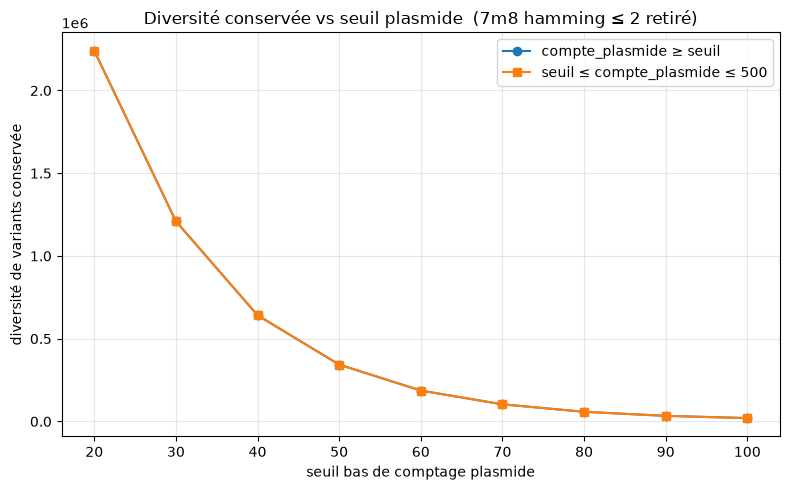

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep.index, sweep.iloc[:, 0], "o-", label="compte_plasmide ≥ seuil")
ax.plot(sweep.index, sweep.iloc[:, 1], "s-", label=f"seuil ≤ compte_plasmide ≤ {PLASMID_MAX}")
ax.set(xlabel="seuil bas de comptage plasmide", ylabel="diversité de variants conservée",
       title="Diversité conservée vs seuil plasmide  (7m8 hamming ≤ 2 retiré)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


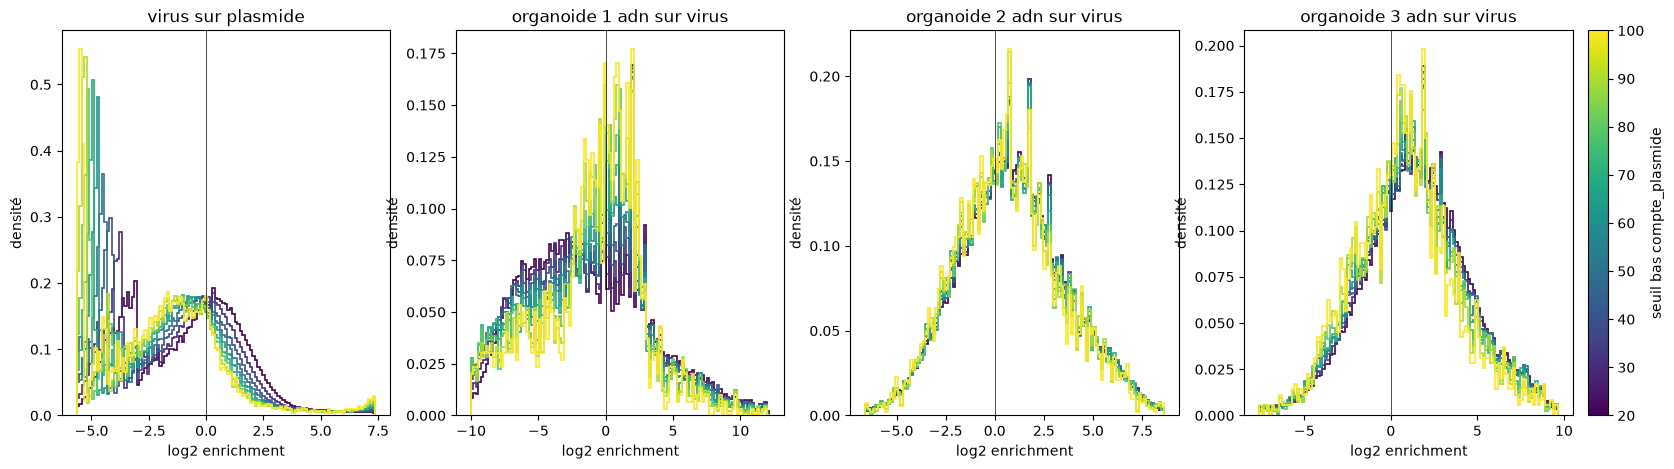

In [13]:
# distributions de log enrichment pour chaque seuil bas (densité, bins partagés par colonne)
enr_cols = [viab_col, *sel_cols]
colors = plt.cm.viridis(np.linspace(0, 1, len(THRS)))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, enr_cols):
    raw = df[col].to_numpy(np.float64)
    fr  = raw[np.isfinite(raw)]
    bins = np.linspace(*np.percentile(fr, [0.2, 99.8]), 120)
    for thr, c in zip(THRS, colors):
        x = raw[not_7m8 & (plasmid >= thr)]
        x = x[np.isfinite(x)]
        ax.hist(x, bins=bins, density=True, histtype="step", color=c, lw=1.2)
    ax.axvline(0, color="k", lw=0.5)
    ax.set(title=col.replace("log2_enrichissement_", "").replace("_", " "),
           xlabel="log2 enrichment", ylabel="densité")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(THRS[0], THRS[-1]))
fig.colorbar(sm, ax=axes.tolist(), label="seuil bas compte_plasmide", fraction=0.015, pad=0.01)
plt.show()


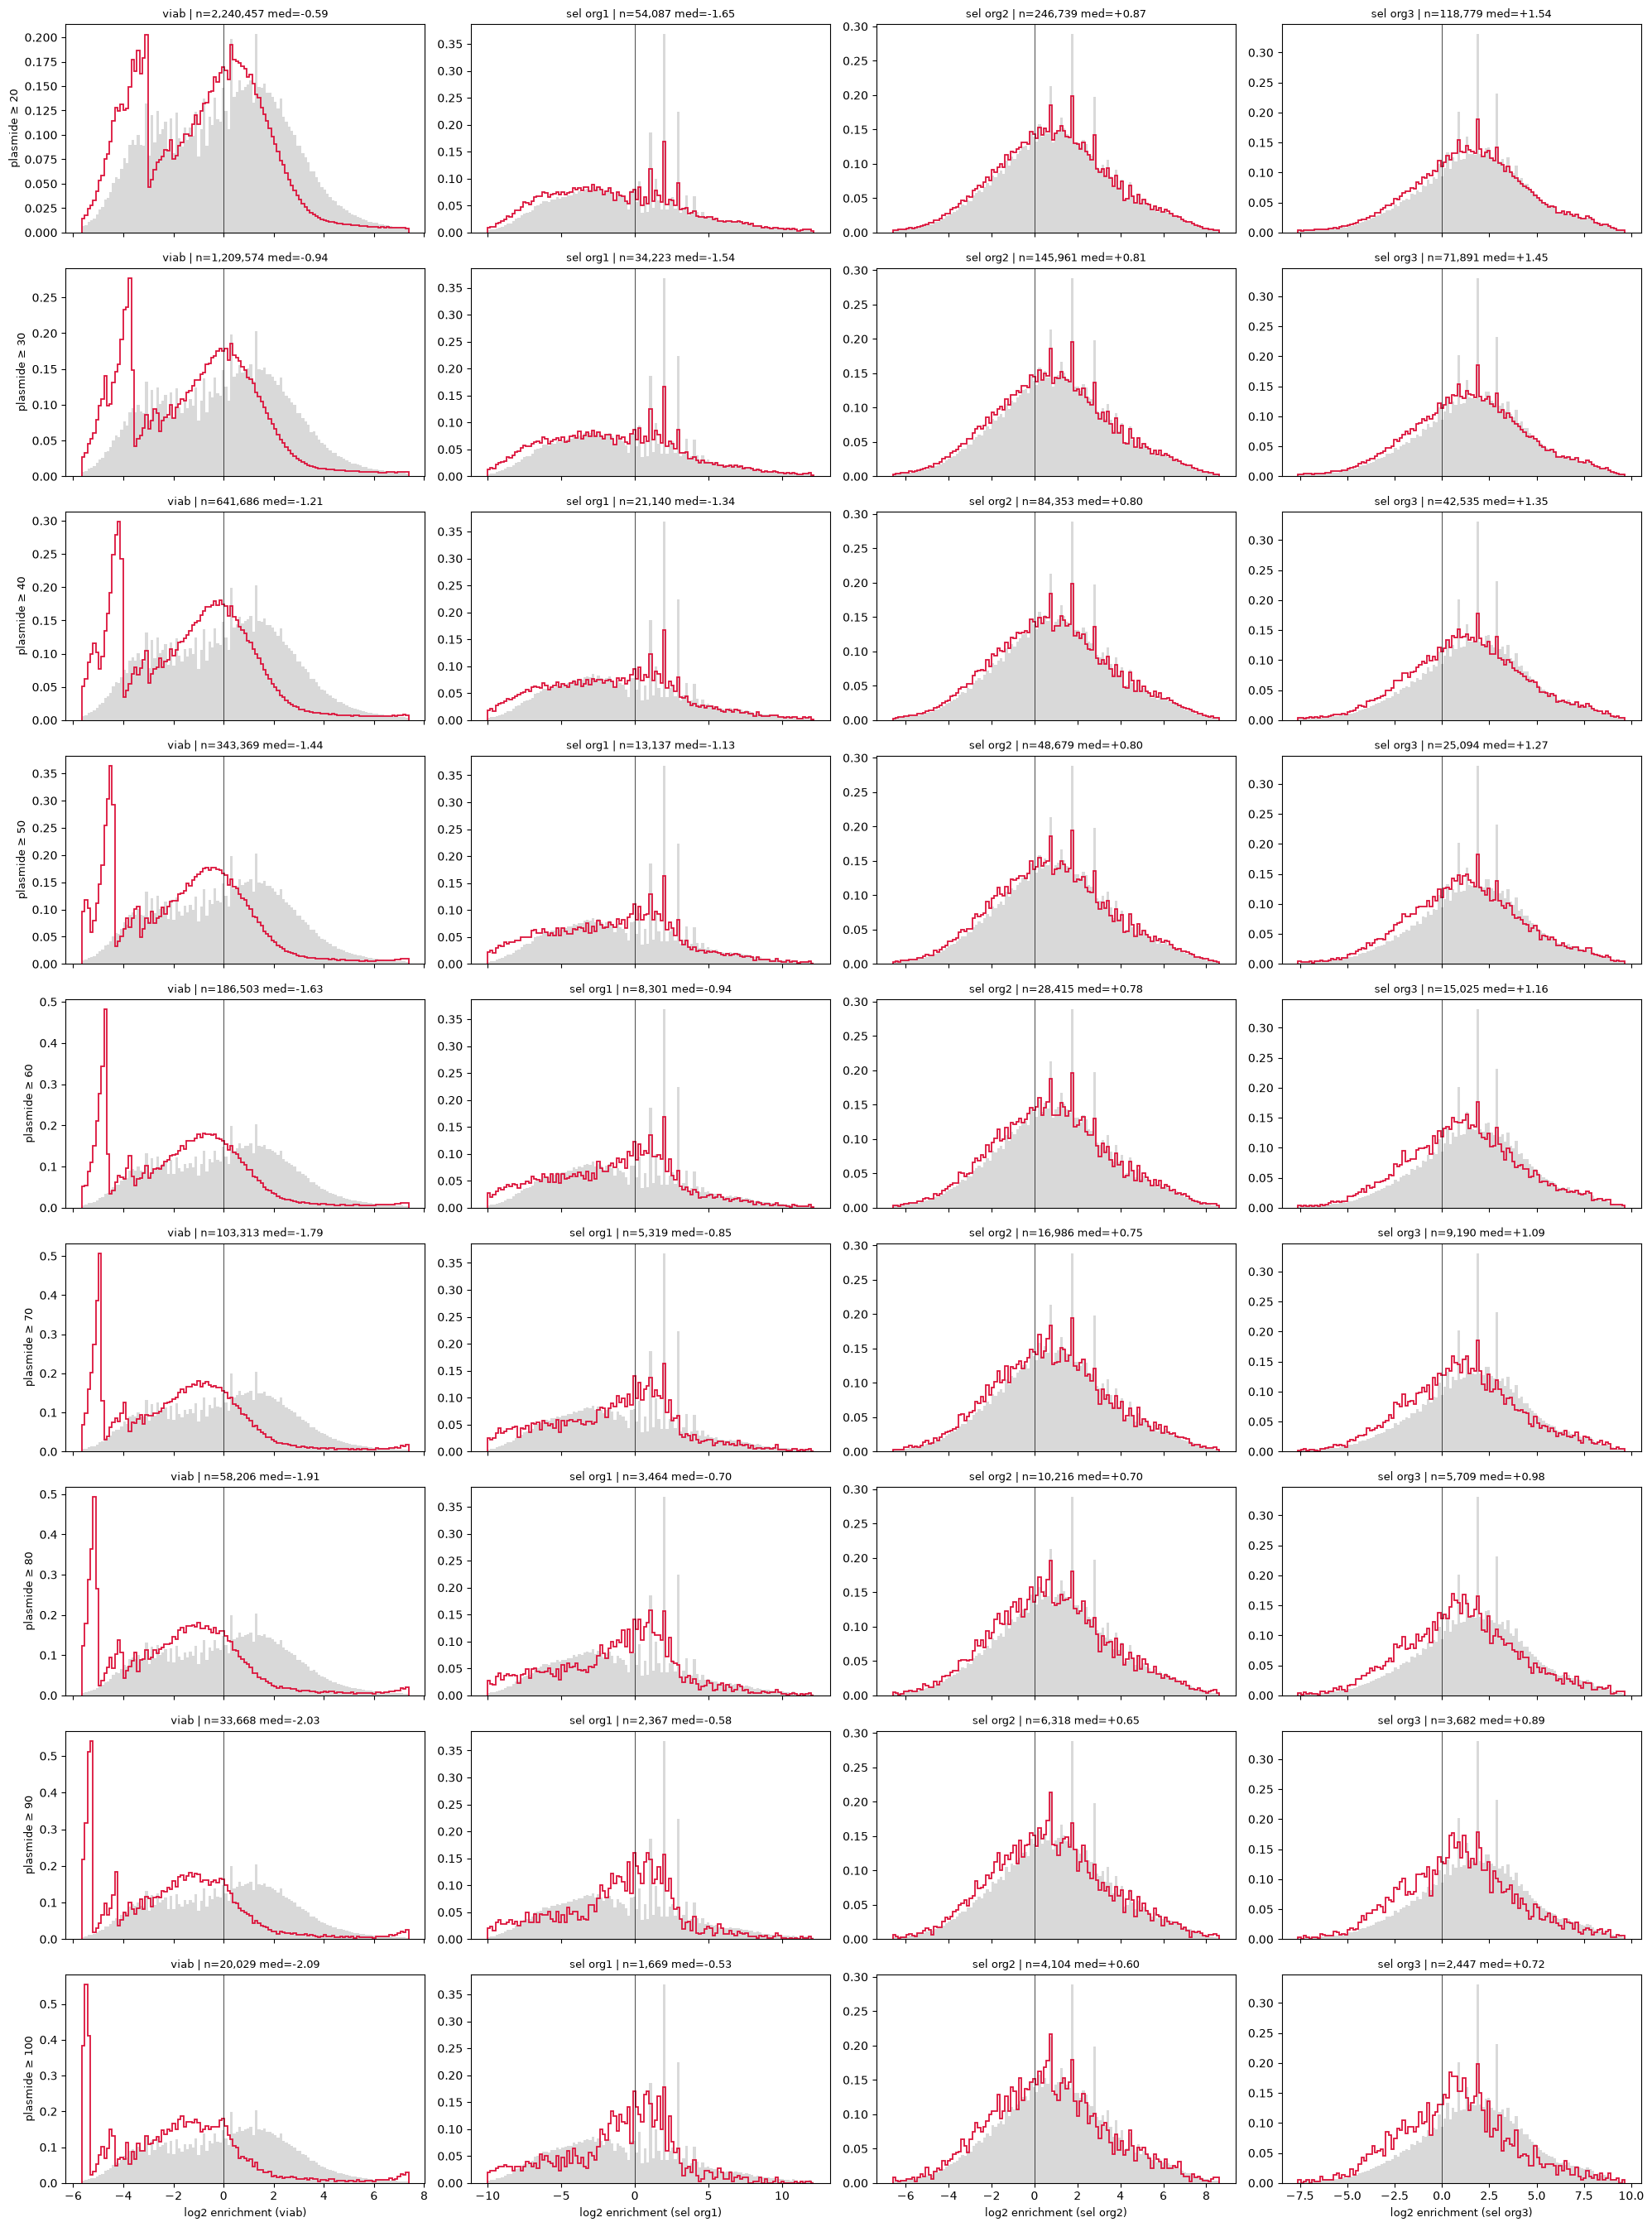

In [14]:
# même chose en grille : une ligne par seuil, une colonne par métrique (backdrop gris = brut)
short_lbl = ["viab", "sel org1", "sel org2", "sel org3"]
fig, axes = plt.subplots(len(THRS), 4, figsize=(20, 3.0 * len(THRS)), sharex="col")
for r, thr in enumerate(THRS):
    keep_thr = not_7m8 & (plasmid >= thr)
    for cc, col in enumerate(enr_cols):
        ax = axes[r, cc]
        raw = df[col].to_numpy(np.float64)
        fr  = raw[np.isfinite(raw)]
        bins = np.linspace(*np.percentile(fr, [0.2, 99.8]), 120)
        x = raw[keep_thr]; x = x[np.isfinite(x)]
        ax.hist(fr, bins=bins, density=True, color="0.85")
        ax.hist(x,  bins=bins, density=True, histtype="step", color="crimson", lw=1.3)
        ax.axvline(0, color="k", lw=0.5)
        med = np.median(x) if x.size else np.nan
        ax.set_title(f"{short_lbl[cc]} | n={x.size:,} med={med:+.2f}", fontsize=9)
        if cc == 0:
            ax.set_ylabel(f"plasmide ≥ {thr}", fontsize=9)
for ax, lbl in zip(axes[-1], short_lbl):
    ax.set_xlabel(f"log2 enrichment ({lbl})", fontsize=9)
plt.tight_layout(); plt.show()


In [15]:
# stats de distribution par seuil (viab + moyenne des 3 réplicats de sélectivité)
sel_mean = df[sel_cols].mean(axis=1, skipna=True).to_numpy(np.float64)
rows = []
for thr in THRS:
    k = not_7m8 & (plasmid >= thr)
    v = df[viab_col].to_numpy(np.float64)[k]; v = v[np.isfinite(v)]
    s = sel_mean[k];                          s = s[np.isfinite(s)]
    rows.append({
        "seuil": int(thr), "n_kept": int(k.sum()),
        "viab_n": v.size, "viab_med": round(float(np.median(v)), 3), "viab_std": round(float(v.std()), 3),
        "sel_n": s.size, "sel_frac_fini": round(s.size / int(k.sum()), 3),
        "sel_med": round(float(np.median(s)), 3), "sel_std": round(float(s.std()), 3),
    })
pd.DataFrame(rows).set_index("seuil")


,n_kept,viab_n,viab_med,viab_std,sel_n,sel_frac_fini,sel_med,sel_std
seuil,,,,,,,,
20,2240457,2240457,-0.587,2.498,288129,0.129,0.963,2.859
30,1209574,1209574,-0.936,2.552,169398,0.140,0.922,2.892
40,641686,641686,-1.213,2.618,97392,0.152,0.906,2.921
50,343369,343369,-1.440,2.695,55913,0.163,0.889,2.932
60,186503,186503,-1.629,2.783,32485,0.174,0.866,2.933
70,103313,103313,-1.787,2.892,19316,0.187,0.824,2.939
80,58206,58206,-1.909,3.014,11583,0.199,0.805,2.931
90,33668,33668,-2.032,3.177,7120,0.211,0.753,2.940
100,20029,20029,-2.090,3.371,4576,0.228,0.668,2.903


## 7. Balayage de la borne supérieure (borne inférieure fixée à 10)

Symétrique de la §6 : `compte_plasmide ≥ 10` fixe, et on fait **décroître la borne supérieure**.
Fenêtre conservée : `10 ≤ compte_plasmide ≤ borne_sup`, `hamming ≤ 2` du 7m8 toujours retiré.
Mêmes sorties : diversité conservée, distributions log2 enrichment par borne, table de stats.


borne inf fixe = 10  |  variants avec plasmide >= 10 (7m8 retiré) : 3,822,487


,diversite,frac_vs_brut
borne_sup,,
500,3822400,0.6831
400,3822347,0.6831
300,3822246,0.6831
200,3821838,0.6830
150,3820246,0.6827
100,3802958,0.6796
80,3765834,0.6730
60,3641554,0.6508
40,3200553,0.5720


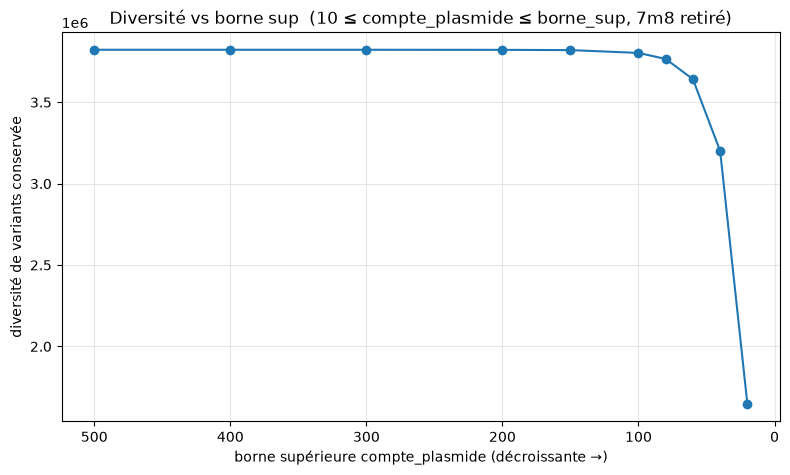

In [16]:
PLASMID_MIN2 = 10                                        # borne inférieure fixe
UPPER_THRS = np.array([500, 400, 300, 200, 150, 100, 80, 60, 40, 20])   # borne sup décroissante

lo_fixed = not_7m8 & (plasmid >= PLASMID_MIN2)
rows = []
for up in UPPER_THRS:
    win = lo_fixed & (plasmid <= up)
    rows.append({"borne_sup": int(up), "diversite": int(win.sum()),
                 "frac_vs_brut": round(int(win.sum()) / len(df), 4)})
sweep_up = pd.DataFrame(rows).set_index("borne_sup")
print(f"borne inf fixe = {PLASMID_MIN2}  |  variants avec plasmide >= 10 (7m8 retiré) : {int(lo_fixed.sum()):,}")
display(sweep_up)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_up.index, sweep_up["diversite"], "o-")
ax.invert_xaxis()
ax.set(xlabel="borne supérieure compte_plasmide (décroissante →)",
       ylabel="diversité de variants conservée",
       title="Diversité vs borne sup  (10 ≤ compte_plasmide ≤ borne_sup, 7m8 retiré)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


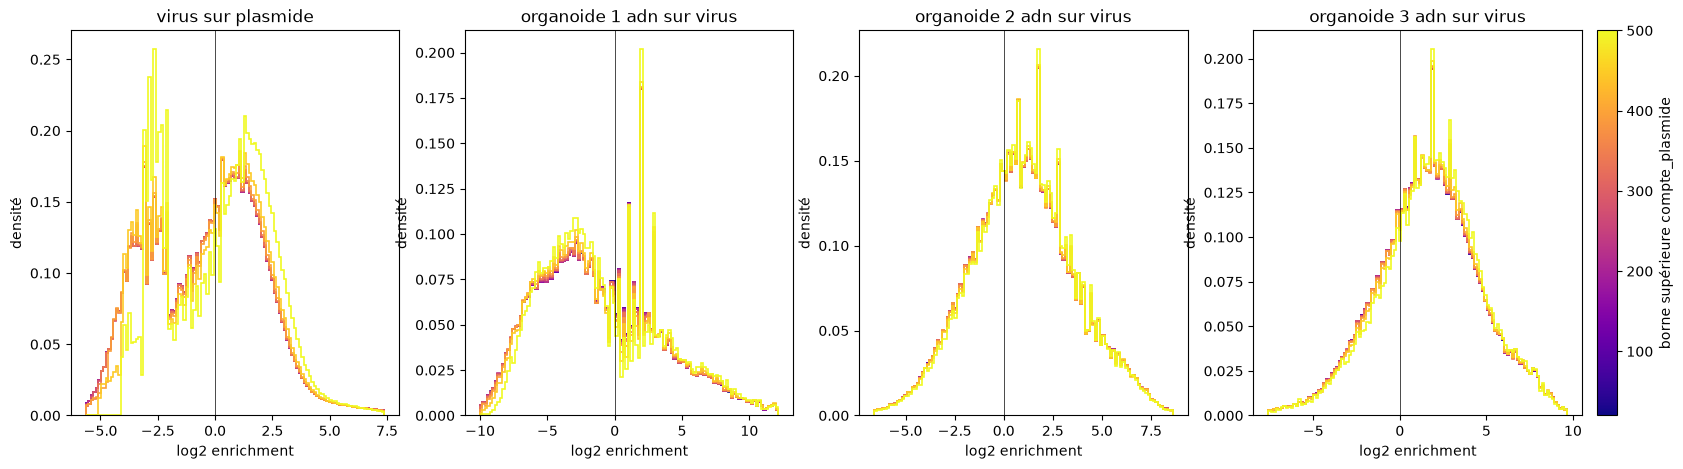

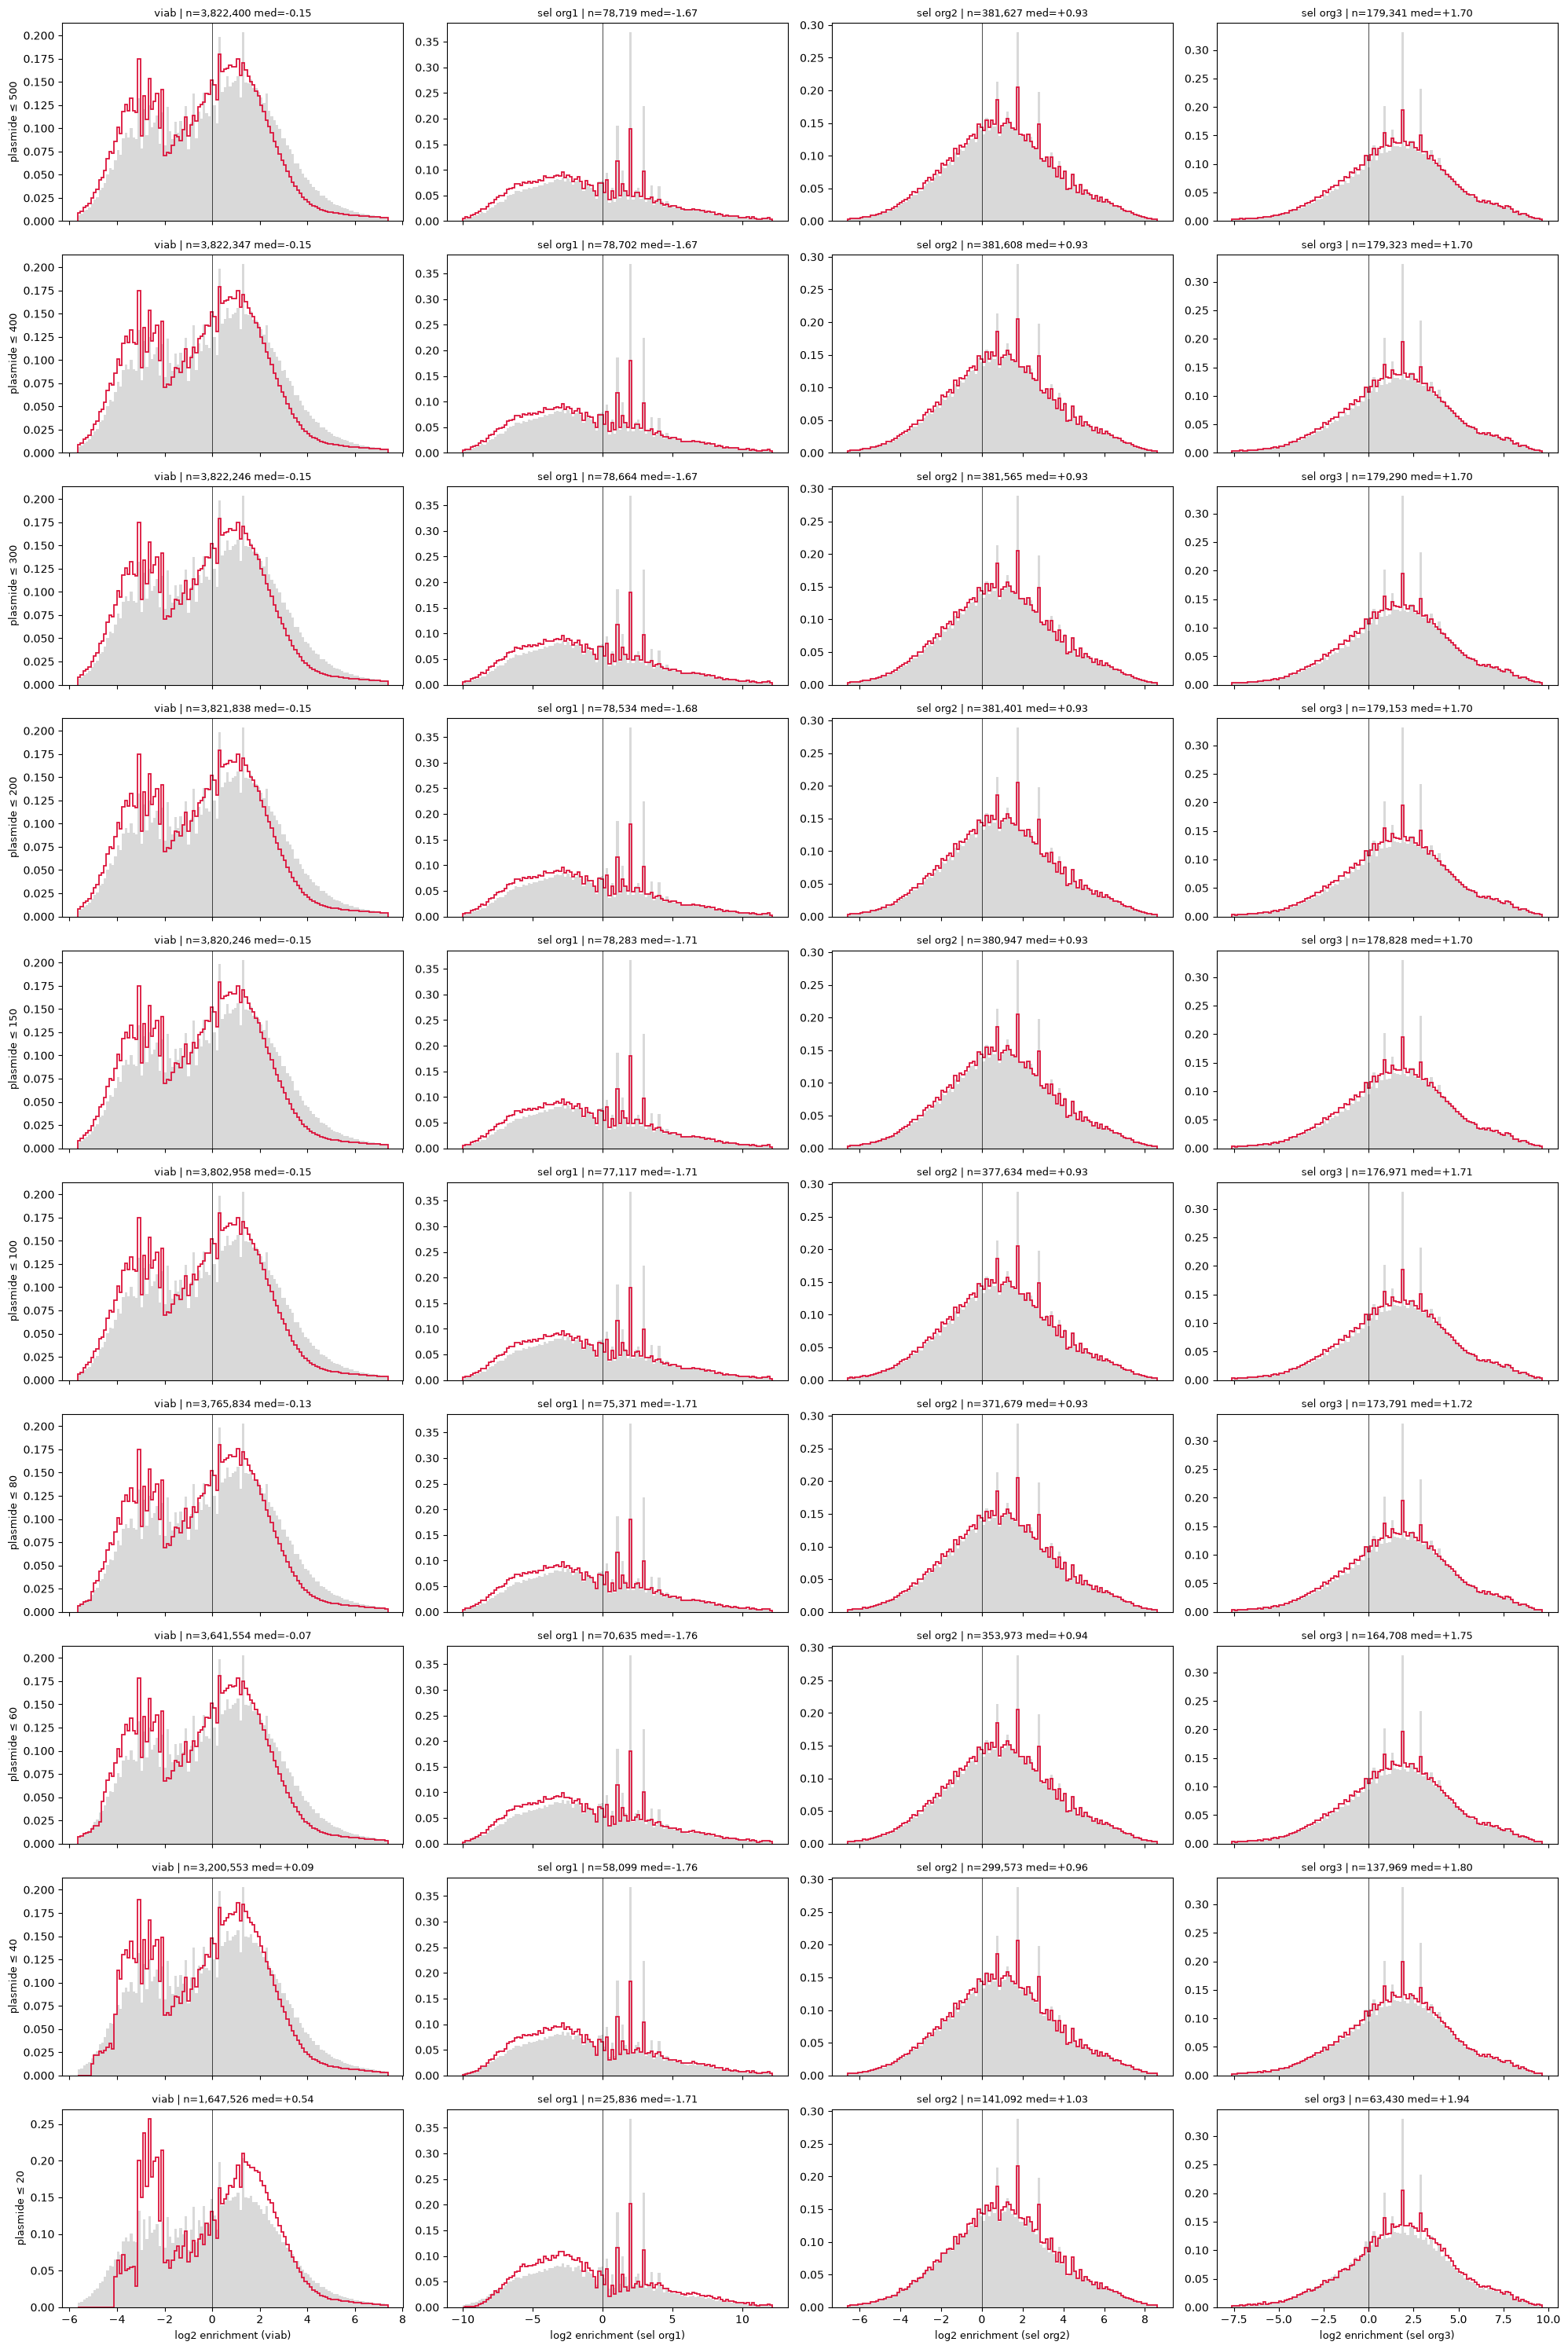

In [17]:
# distributions log2 enrichment par borne supérieure — overlay (couleur = borne_sup)
colors_up = plt.cm.plasma(np.linspace(0, 1, len(UPPER_THRS)))
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, enr_cols):
    raw = df[col].to_numpy(np.float64)
    fr  = raw[np.isfinite(raw)]
    bins = np.linspace(*np.percentile(fr, [0.2, 99.8]), 120)
    for up, c in zip(UPPER_THRS, colors_up):
        x = raw[lo_fixed & (plasmid <= up)]
        x = x[np.isfinite(x)]
        ax.hist(x, bins=bins, density=True, histtype="step", color=c, lw=1.2)
    ax.axvline(0, color="k", lw=0.5)
    ax.set(title=col.replace("log2_enrichissement_", "").replace("_", " "),
           xlabel="log2 enrichment", ylabel="densité")
sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(UPPER_THRS.min(), UPPER_THRS.max()))
fig.colorbar(sm, ax=axes.tolist(), label="borne supérieure compte_plasmide", fraction=0.015, pad=0.01)
plt.show()

# grille : une ligne par borne_sup, backdrop gris = brut
fig, axes = plt.subplots(len(UPPER_THRS), 4, figsize=(20, 3.0 * len(UPPER_THRS)), sharex="col")
for r, up in enumerate(UPPER_THRS):
    win = lo_fixed & (plasmid <= up)
    for cc, col in enumerate(enr_cols):
        ax = axes[r, cc]
        raw = df[col].to_numpy(np.float64)
        fr  = raw[np.isfinite(raw)]
        bins = np.linspace(*np.percentile(fr, [0.2, 99.8]), 120)
        x = raw[win]; x = x[np.isfinite(x)]
        ax.hist(fr, bins=bins, density=True, color="0.85")
        ax.hist(x,  bins=bins, density=True, histtype="step", color="crimson", lw=1.3)
        ax.axvline(0, color="k", lw=0.5)
        med = np.median(x) if x.size else np.nan
        ax.set_title(f"{short_lbl[cc]} | n={x.size:,} med={med:+.2f}", fontsize=9)
        if cc == 0:
            ax.set_ylabel(f"plasmide ≤ {up}", fontsize=9)
for ax, lbl in zip(axes[-1], short_lbl):
    ax.set_xlabel(f"log2 enrichment ({lbl})", fontsize=9)
plt.tight_layout(); plt.show()


In [18]:
# stats de distribution par borne supérieure (viab + moyenne des 3 réplicats de sélectivité)
rows = []
for up in UPPER_THRS:
    win = lo_fixed & (plasmid <= up)
    v = df[viab_col].to_numpy(np.float64)[win]; v = v[np.isfinite(v)]
    s = sel_mean[win];                          s = s[np.isfinite(s)]
    rows.append({
        "borne_sup": int(up), "n_kept": int(win.sum()),
        "viab_n": v.size, "viab_med": round(float(np.median(v)), 3), "viab_std": round(float(v.std()), 3),
        "sel_n": s.size, "sel_frac_fini": round(s.size / int(win.sum()), 3),
        "sel_med": round(float(np.median(s)), 3), "sel_std": round(float(s.std()), 3),
    })
pd.DataFrame(rows).set_index("borne_sup")


,n_kept,viab_n,viab_med,viab_std,sel_n,sel_frac_fini,sel_med,sel_std
borne_sup,,,,,,,,
500,3822400,3822400,-0.154,2.474,448428,0.117,1.027,2.815
400,3822347,3822347,-0.154,2.474,448406,0.117,1.027,2.815
300,3822246,3822246,-0.154,2.474,448362,0.117,1.027,2.815
200,3821838,3821838,-0.154,2.473,448192,0.117,1.027,2.815
150,3820246,3820246,-0.154,2.472,447700,0.117,1.028,2.814
100,3802958,3802958,-0.145,2.466,443984,0.117,1.031,2.813
80,3765834,3765834,-0.128,2.457,437157,0.116,1.034,2.811
60,3641554,3641554,-0.070,2.437,416827,0.114,1.039,2.805
40,3200553,3200553,0.091,2.392,353710,0.111,1.061,2.784
